# RNN


## RNN 핵심 개념

RNN의 기본 계산은 다음과 같이 이해할 수 있습니다.

- 현재 입력 토큰을 embedding 벡터로 바꿉니다.
- 이전 hidden state와 현재 입력을 함께 사용해 새로운 hidden state를 만듭니다.
- hidden state를 이용해 다음 토큰의 확률 분포를 예측합니다.

장점은 순서를 반영할 수 있다는 점입니다. 단점은 문장이 길어질수록 초반 정보가 뒤쪽까지 잘 전달되지 않는 vanishing gradient 문제가 발생하기 쉽다는 점입니다.

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [3]:
sentences = [
    "고객은 배송이 빠르다고 말했다.",
    "고객은 배송이 늦다고 말했다.",
    "리뷰는 상품 품질이 좋다고 평가했다.",
    "리뷰는 고객센터 연결이 어렵다고 평가했다.",
    "사용자는 결제 오류 때문에 주문을 취소했다.",
    "사용자는 쿠폰 혜택 때문에 다시 주문했다.",
    "앱 업데이트 이후 화면이 불편하다.",
    "앱 검색 기능이 편리하다.",
]

In [4]:
text = "\n".join(sentences * 40)
chars = sorted(set(text))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

encoded = torch.tensor([stoi[ch] for ch in text], dtype=torch.long)
vocab_size = len(chars)

print("전체 문자 수:", len(encoded))
print("문자 어휘 크기:", vocab_size)
print("어휘 일부:", chars[:30])

전체 문자 수: 6559
문자 어휘 크기: 62
어휘 일부: ['\n', ' ', '.', '가', '객', '검', '결', '고', '기', '는', '능', '늦', '다', '데', '때', '렵', '류', '르', '리', '말', '면', '문', '배', '불', '뷰', '빠', '사', '상', '색', '센']


## 학습 데이터 만들기

문자 단위 언어모델에서는 길이 `block_size`만큼의 입력 문자 시퀀스를 만들고, 정답은 입력을 한 칸 오른쪽으로 민 시퀀스로 만듭니다.

예를 들어 입력이 `고객은`이면 정답은 `객은 `입니다. 모델은 매 위치에서 다음 문자를 맞히도록 학습됩니다.

In [5]:
block_size = 24     # 한 번에 입력으로 볼 문자 길이

class CharDataset(Dataset):
    def __init__(self, data, block_size):
        self.data = data
        self.block_size = block_size

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        chunk = self.data[idx:idx + self.block_size + 1]
        x = chunk[:-1]
        y = chunk[1:]
        return x, y

dataset = CharDataset(encoded, block_size)
loader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)

xb, yb = next(iter(loader))
print("입력 shape:", xb.shape)
print("정답 shape:", yb.shape)
print("입력 예시:", "".join(itos[int(i)] for i in xb[0]))
print("정답 예시:", "".join(itos[int(i)] for i in yb[0]))

입력 shape: torch.Size([64, 24])
정답 shape: torch.Size([64, 24])
입력 예시: 다.
고객은 배송이 늦다고 말했다.
리뷰는 
정답 예시: .
고객은 배송이 늦다고 말했다.
리뷰는 상


## RNN 언어모델 정의

모델 구조는 `Embedding -> RNN -> Linear`입니다.

- Embedding: 문자를 벡터로 변환합니다.
- RNN: 순서대로 문맥 정보를 누적합니다.
- Linear: 각 위치에서 다음 문자 후보에 대한 점수를 출력합니다.

In [4]:
class CharRNNLM(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)
        out, hidden = self.rnn(emb, hidden)
        logits = self.fc(out)
        return logits, hidden

model = CharRNNLM(vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

print(model)

CharRNNLM(
  (embedding): Embedding(62, 32)
  (rnn): RNN(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=62, bias=True)
)


In [5]:
epochs = 15
losses = []

for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits, _ = model(x_batch)
        loss = criterion(logits.reshape(-1, vocab_size), y_batch.reshape(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch:02d} | loss: {avg_loss:.4f}")

Epoch 01 | loss: 1.1947
Epoch 02 | loss: 0.1628
Epoch 03 | loss: 0.1037
Epoch 04 | loss: 0.0873
Epoch 05 | loss: 0.0800
Epoch 06 | loss: 0.0746
Epoch 07 | loss: 0.0724
Epoch 08 | loss: 0.0709
Epoch 09 | loss: 0.0704
Epoch 10 | loss: 0.0699
Epoch 11 | loss: 0.0693
Epoch 12 | loss: 0.0689
Epoch 13 | loss: 0.0686
Epoch 14 | loss: 0.0685
Epoch 15 | loss: 0.0684


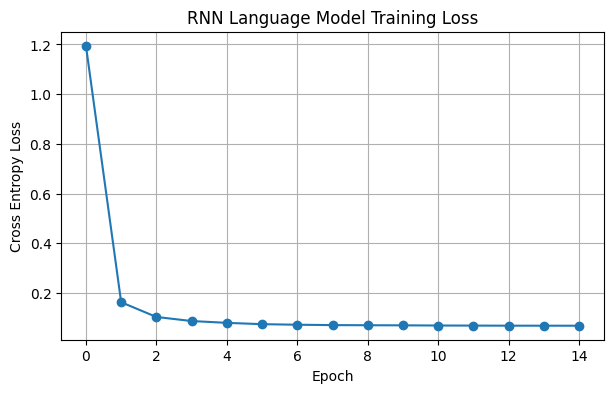

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(losses, marker="o")
plt.title("RNN Language Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.grid(True)
plt.show()

## 텍스트 생성

학습된 모델은 시작 문자열을 입력받아 다음 문자를 하나씩 샘플링할 수 있습니다.

In [ ]:
def generate_text(model, start="고객", max_new_chars=80, temperature=0.8):
    model.eval()
    ids = [stoi.get(ch, 0) for ch in start]
    x = torch.tensor([ids], dtype=torch.long, device=device)

    with torch.no_grad():
        for _ in range(max_new_chars):
            x_cond = x[:, -block_size:]
            logits, _ = model(x_cond)
            logits = logits[:, -1, :] / temperature
            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            x = torch.cat([x, next_id], dim=1)

    return "".join(itos[int(i)] for i in x[0].cpu())

print(generate_text(model, start="고객", max_new_chars=100, temperature=0.8))

고객은 배송이 늦다고 말했다.
리뷰는 상품 품질이 좋다고 평가했다.
리뷰는 고객센터 연결이 어렵다고 평가했다.
사용자는 결제 오류 때문에 주문을 취소했다.
사용자는 쿠폰 혜택 때문에 
